# Latent Liquidity Financial Data Visualization

This notebook visualizes the processed financial data for latent liquidity modeling, including:
- Asset returns (SPY, TLT, HYG)
- Market volatility (VIX)
- Credit spreads (ICE BofA IG)
- Rolling correlations between assets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load processed financial data
print("Loading processed financial data...")

# Load numpy arrays
observations = np.load('data/processed/observations.npy')
returns = np.load('data/processed/returns.npy')
dates = np.load('data/processed/dates.npy')

print(f"Observations shape: {observations.shape}")
print(f"Returns shape: {returns.shape}")
print(f"Dates shape: {dates.shape}")
print(f"Date range: {dates[0]} to {dates[-1]}")

# Create DataFrame for easier plotting
df = pd.DataFrame({
    'date': dates,
    'r_SPY': returns[:, 0],
    'r_TLT': returns[:, 1],
    'r_HYG': returns[:, 2],
    'VIX': observations[:, 3],
    'IG_Spread': observations[:, 4],
    'rolling_corr': observations[:, 5]
})

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print(f"DataFrame shape: {df.shape}")
print("Data loaded successfully!")

Loading processed financial data...
Observations shape: (4526, 6)
Returns shape: (4526, 3)
Dates shape: (4526,)
Date range: 2007-04-13T00:00:00.000000000 to 2026-03-06T00:00:00.000000000
DataFrame shape: (4526, 6)
Data loaded successfully!


In [3]:
# Data Overview and Statistics
print("=== DATA OVERVIEW ===")
print(df.head())
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

print("\n=== CORRELATION MATRIX ===")
correlation_matrix = df[['r_SPY', 'r_TLT', 'r_HYG', 'VIX', 'IG_Spread']].corr()
print(correlation_matrix)

=== DATA OVERVIEW ===
               r_SPY     r_TLT     r_HYG    VIX  IG_Spread  rolling_corr
date                                                                    
2007-04-13  0.004552 -0.003095 -0.001821  12.20       2.71     -0.090549
2007-04-16  0.009452  0.005495 -0.000383  11.98       2.70      0.126745
2007-04-17  0.002655  0.005577 -0.000480  12.14       2.72      0.106377
2007-04-18  0.001223  0.004983  0.000288  12.42       2.73      0.055604
2007-04-19 -0.000272 -0.001696  0.003450  12.54       2.71     -0.309758

=== SUMMARY STATISTICS ===
             r_SPY        r_TLT        r_HYG          VIX    IG_Spread  \
count  4526.000000  4526.000000  4526.000000  4526.000000  4526.000000   
mean      0.000387     0.000200     0.000241    19.900420     5.220183   
std       0.012432     0.009501     0.006935     8.798163     2.684690   
min      -0.115887    -0.069010    -0.084441     9.140000     2.410000   
25%      -0.004141    -0.005565    -0.001857    14.120000     3.64000

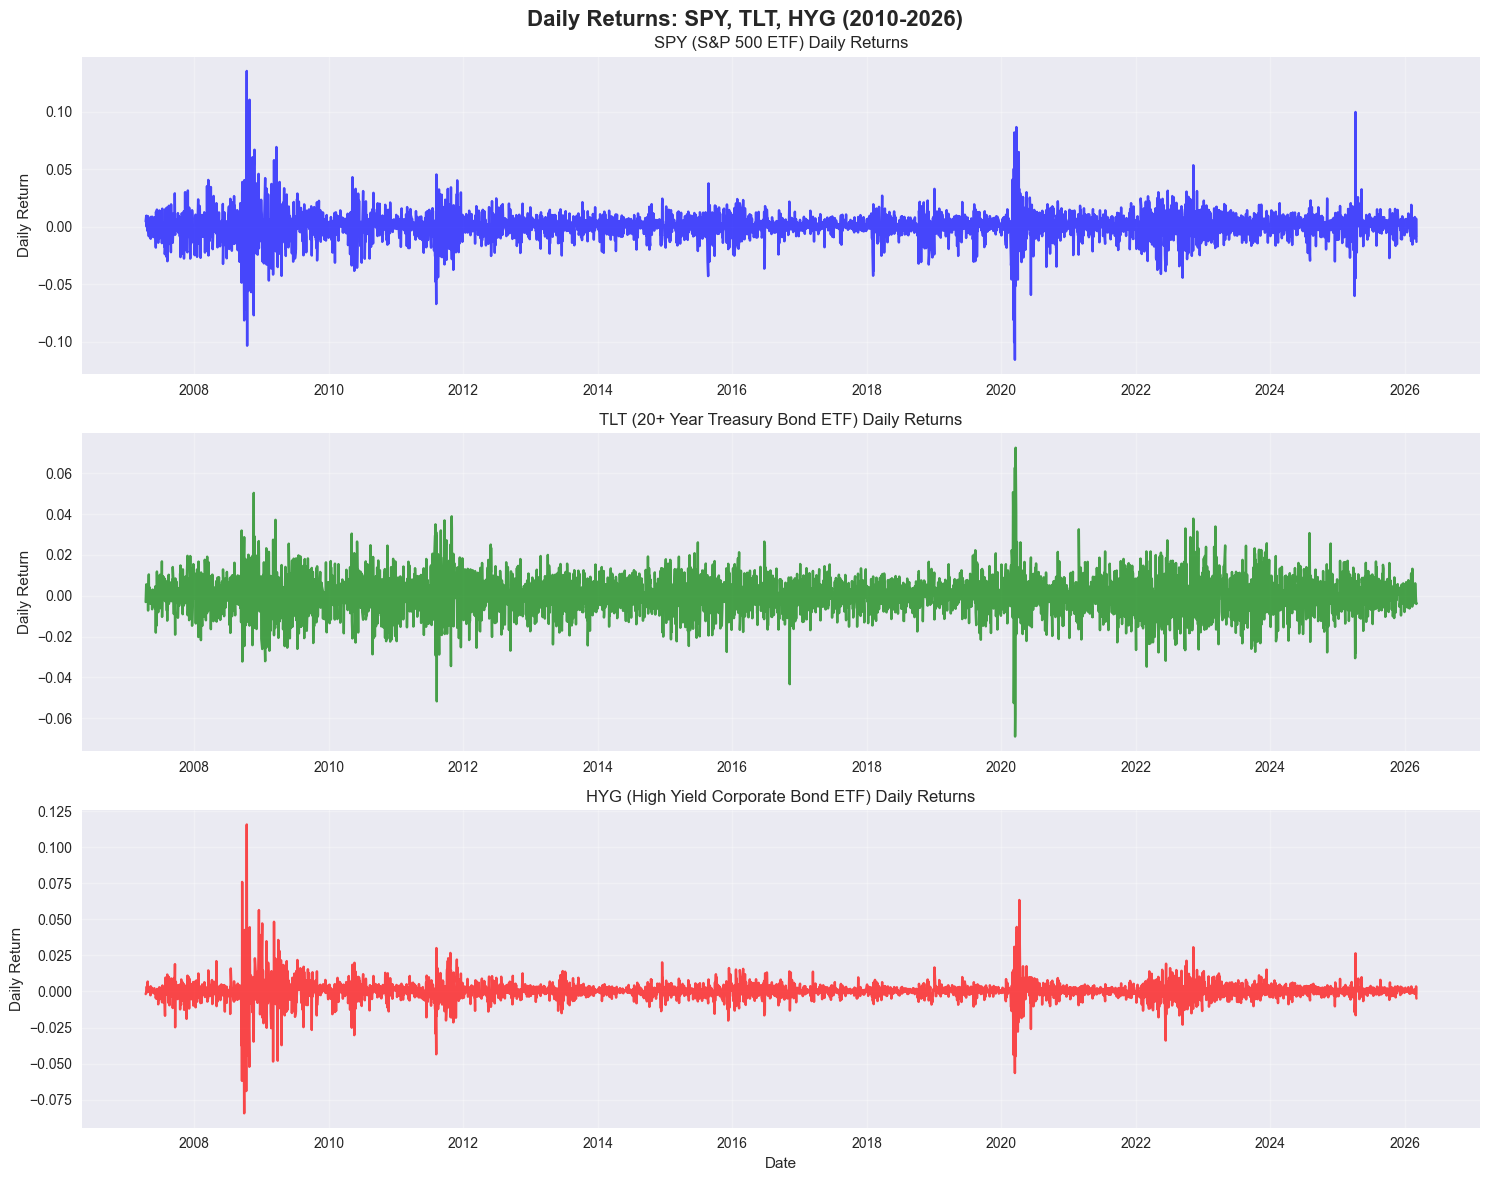

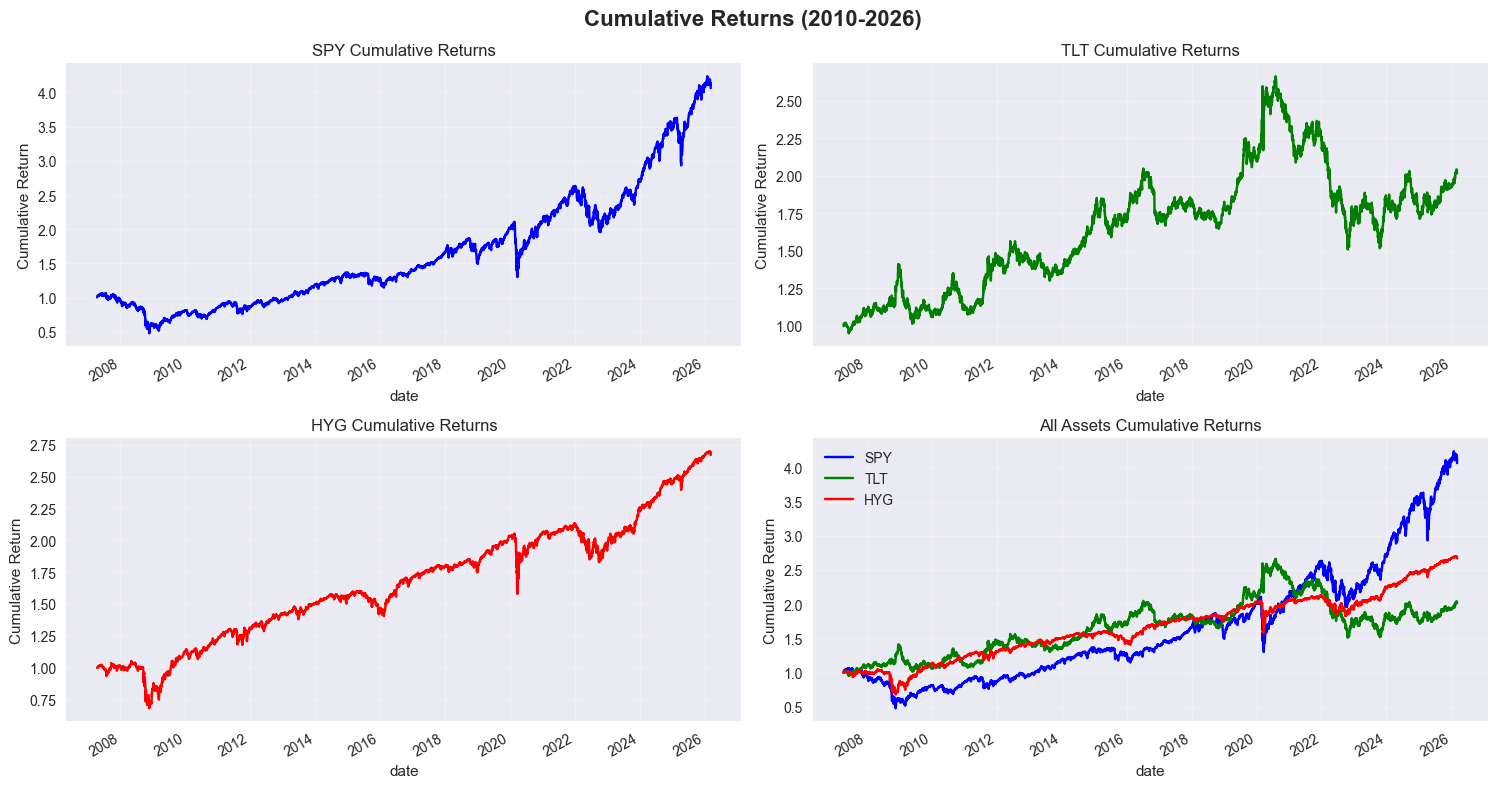

In [4]:
# Asset Returns Time Series
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Daily Returns: SPY, TLT, HYG (2010-2026)', fontsize=16, fontweight='bold')

# SPY returns
axes[0].plot(df.index, df['r_SPY'], color='blue', alpha=0.7)
axes[0].set_title('SPY (S&P 500 ETF) Daily Returns')
axes[0].set_ylabel('Daily Return')
axes[0].grid(True, alpha=0.3)

# TLT returns
axes[1].plot(df.index, df['r_TLT'], color='green', alpha=0.7)
axes[1].set_title('TLT (20+ Year Treasury Bond ETF) Daily Returns')
axes[1].set_ylabel('Daily Return')
axes[1].grid(True, alpha=0.3)

# HYG returns
axes[2].plot(df.index, df['r_HYG'], color='red', alpha=0.7)
axes[2].set_title('HYG (High Yield Corporate Bond ETF) Daily Returns')
axes[2].set_ylabel('Daily Return')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cumulative returns
plt.figure(figsize=(15, 8))
plt.suptitle('Cumulative Returns (2010-2026)', fontsize=16, fontweight='bold')

plt.subplot(2, 2, 1)
(1 + df['r_SPY']).cumprod().plot(color='blue')
plt.title('SPY Cumulative Returns')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
(1 + df['r_TLT']).cumprod().plot(color='green')
plt.title('TLT Cumulative Returns')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
(1 + df['r_HYG']).cumprod().plot(color='red')
plt.title('HYG Cumulative Returns')
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
for col, color, label in [('r_SPY', 'blue', 'SPY'), ('r_TLT', 'green', 'TLT'), ('r_HYG', 'red', 'HYG')]:
    (1 + df[col]).cumprod().plot(color=color, label=label)
plt.title('All Assets Cumulative Returns')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

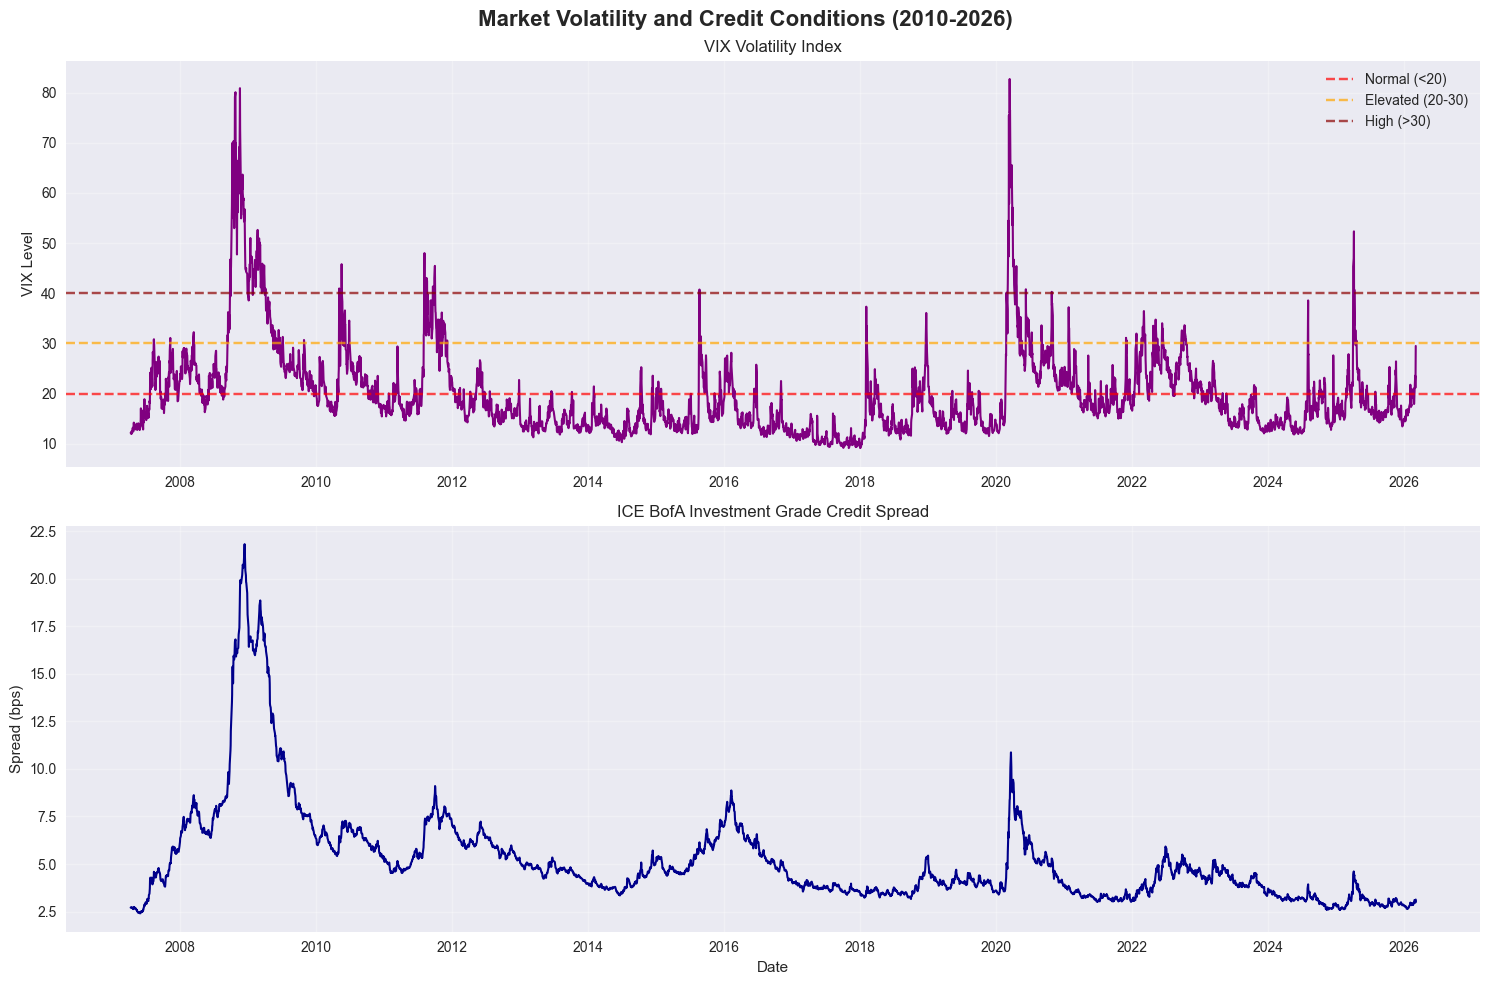

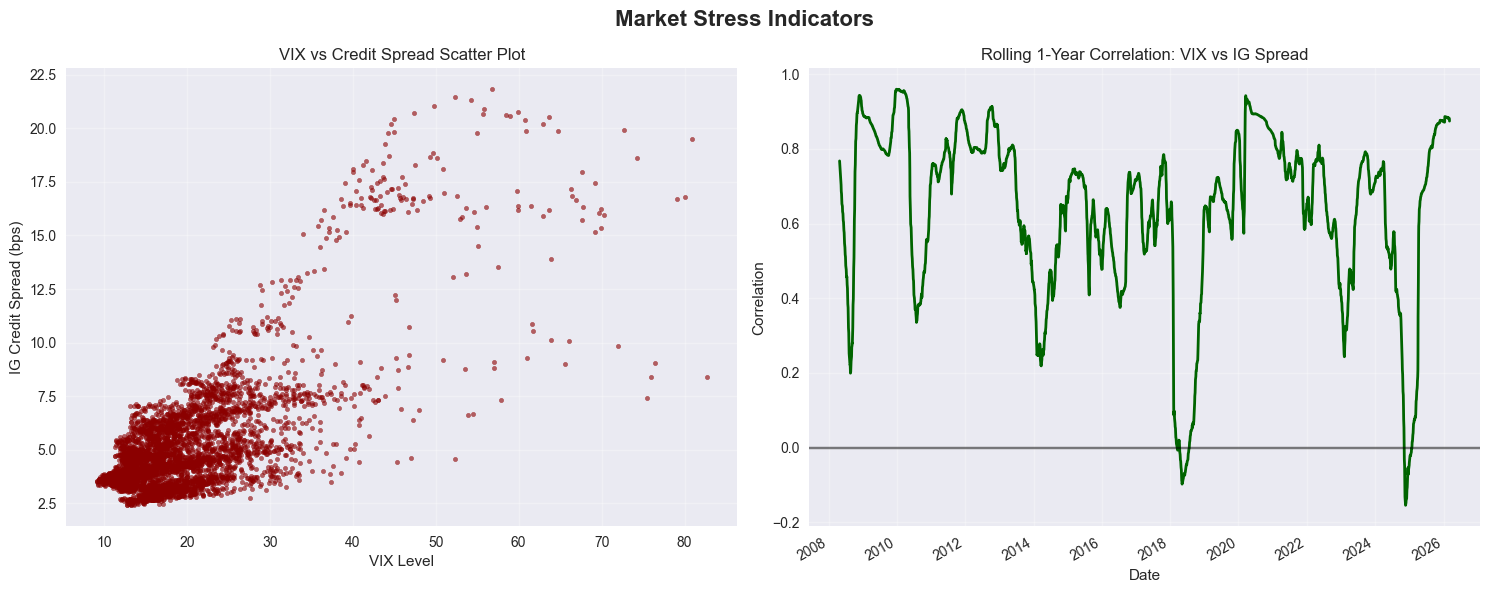

In [5]:
# Market Volatility and Credit Spreads
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Market Volatility and Credit Conditions (2010-2026)', fontsize=16, fontweight='bold')

# VIX (volatility index)
axes[0].plot(df.index, df['VIX'], color='purple', linewidth=1.5)
axes[0].set_title('VIX Volatility Index')
axes[0].set_ylabel('VIX Level')
axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='Normal (<20)')
axes[0].axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Elevated (20-30)')
axes[0].axhline(y=40, color='darkred', linestyle='--', alpha=0.7, label='High (>30)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Credit spreads
axes[1].plot(df.index, df['IG_Spread'], color='darkblue', linewidth=1.5)
axes[1].set_title('ICE BofA Investment Grade Credit Spread')
axes[1].set_ylabel('Spread (bps)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Highlight crisis periods
plt.figure(figsize=(15, 6))
plt.suptitle('Market Stress Indicators', fontsize=16, fontweight='bold')

plt.subplot(1, 2, 1)
plt.scatter(df['VIX'], df['IG_Spread'], alpha=0.6, color='darkred', s=10)
plt.xlabel('VIX Level')
plt.ylabel('IG Credit Spread (bps)')
plt.title('VIX vs Credit Spread Scatter Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Rolling correlation between VIX and spreads
vix_spread_corr = df[['VIX', 'IG_Spread']].rolling(252).corr().unstack()['VIX']['IG_Spread']
vix_spread_corr.plot(color='darkgreen', linewidth=2)
plt.title('Rolling 1-Year Correlation: VIX vs IG Spread')
plt.ylabel('Correlation')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

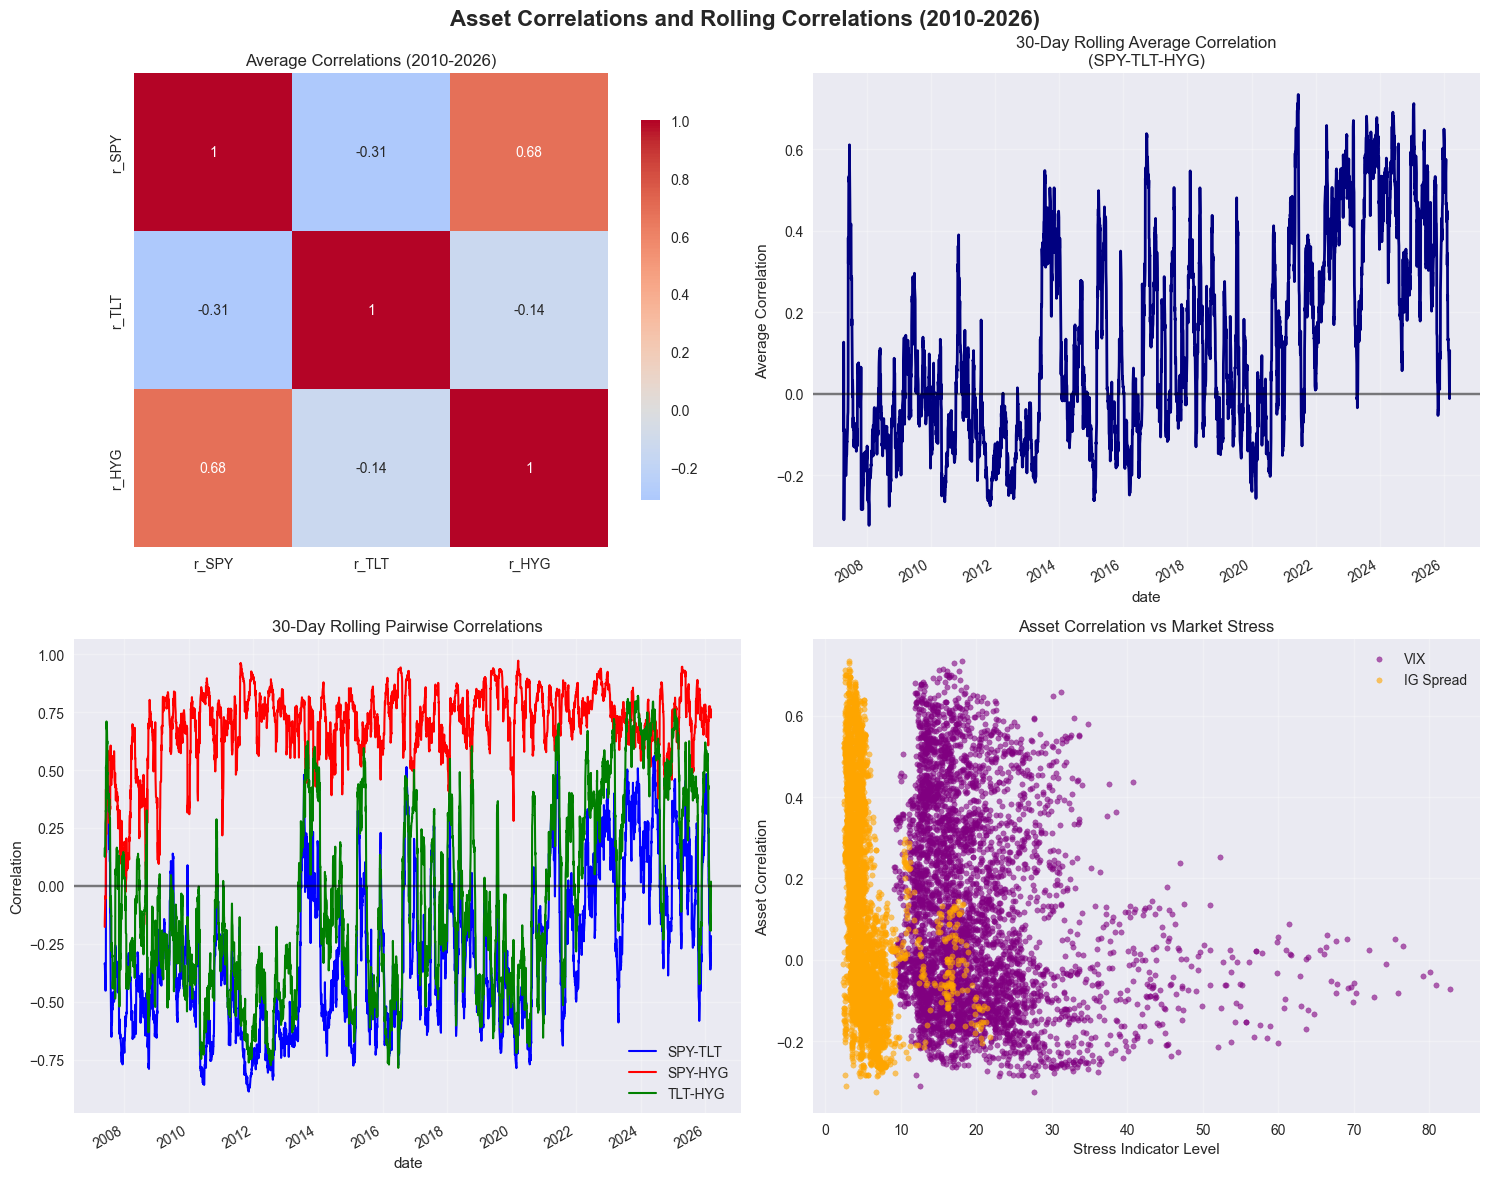

In [6]:
# Rolling Correlations Analysis
plt.figure(figsize=(15, 12))
plt.suptitle('Asset Correlations and Rolling Correlations (2010-2026)', fontsize=16, fontweight='bold')

# Static correlation heatmap
plt.subplot(2, 2, 1)
correlation_matrix = df[['r_SPY', 'r_TLT', 'r_HYG']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Average Correlations (2010-2026)')

# Rolling correlations over time
plt.subplot(2, 2, 2)
df['rolling_corr'].plot(color='navy', linewidth=2)
plt.title('30-Day Rolling Average Correlation\n(SPY-TLT-HYG)')
plt.ylabel('Average Correlation')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Pairwise rolling correlations
plt.subplot(2, 2, 3)
spy_tlt_corr = df[['r_SPY', 'r_TLT']].rolling(30).corr().unstack()['r_SPY']['r_TLT']
spy_hyg_corr = df[['r_SPY', 'r_HYG']].rolling(30).corr().unstack()['r_SPY']['r_HYG']
tlt_hyg_corr = df[['r_TLT', 'r_HYG']].rolling(30).corr().unstack()['r_TLT']['r_HYG']

spy_tlt_corr.plot(label='SPY-TLT', color='blue', linewidth=1.5)
spy_hyg_corr.plot(label='SPY-HYG', color='red', linewidth=1.5)
tlt_hyg_corr.plot(label='TLT-HYG', color='green', linewidth=1.5)

plt.title('30-Day Rolling Pairwise Correlations')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Correlation vs market stress
plt.subplot(2, 2, 4)
stress_corr = pd.DataFrame({
    'correlation': df['rolling_corr'],
    'vix': df['VIX'],
    'spread': df['IG_Spread']
})

plt.scatter(stress_corr['vix'], stress_corr['correlation'],
           alpha=0.6, color='purple', s=15, label='VIX')
plt.scatter(stress_corr['spread'], stress_corr['correlation'],
           alpha=0.6, color='orange', s=15, label='IG Spread')

plt.xlabel('Stress Indicator Level')
plt.ylabel('Asset Correlation')
plt.title('Asset Correlation vs Market Stress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

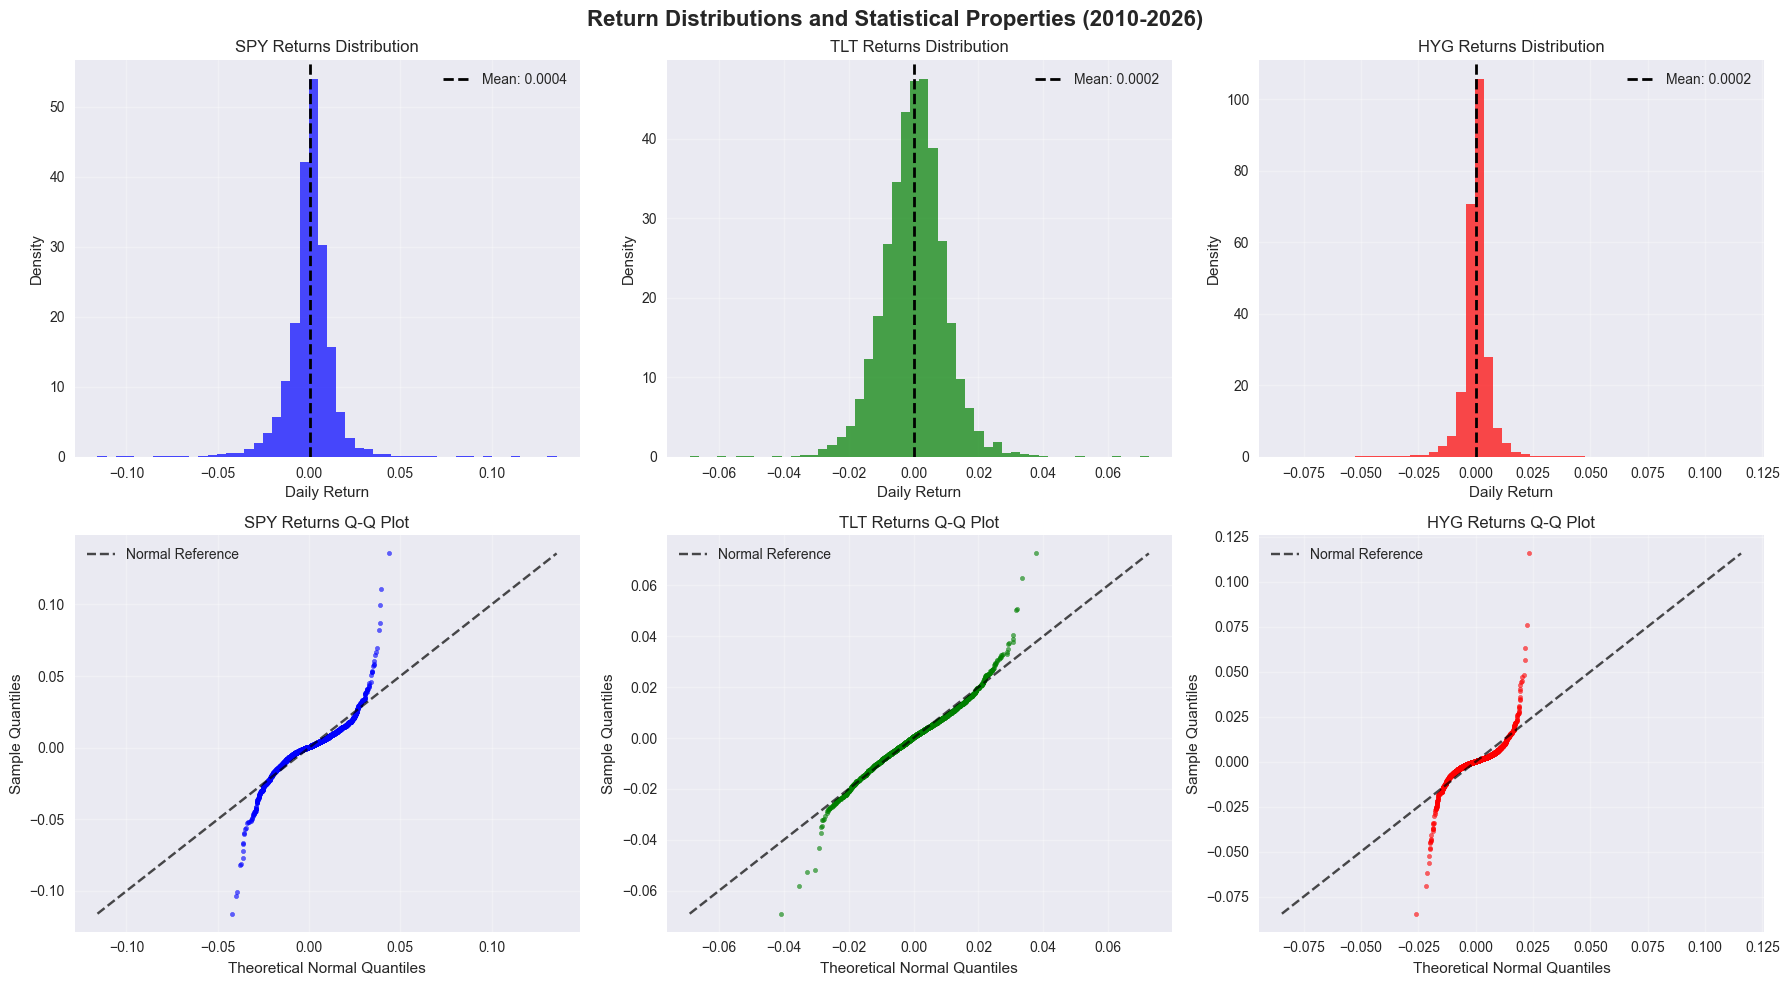

=== RETURN STATISTICS SUMMARY ===
             r_SPY        r_TLT        r_HYG
count  4526.000000  4526.000000  4526.000000
mean      0.000387     0.000200     0.000241
std       0.012432     0.009501     0.006935
min      -0.115887    -0.069010    -0.084441
25%      -0.004141    -0.005565    -0.001857
50%       0.000692     0.000537     0.000340
75%       0.005936     0.005790     0.002505
max       0.135578     0.072503     0.115726

=== SKEWNESS AND KURTOSIS ===
r_SPY: Skewness = -0.2050, Kurtosis = 13.9555
r_TLT: Skewness = 0.0108, Kurtosis = 3.3354
r_HYG: Skewness = 0.3306, Kurtosis = 40.1056

=== VOLATILITY ANALYSIS ===
VIX Average: 19.90
VIX Maximum: 82.69
VIX Minimum: 9.14
IG Spread Average: 5.22 bps
IG Spread Maximum: 21.82 bps
IG Spread Minimum: 2.41 bps


In [7]:
# Statistical Distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Return Distributions and Statistical Properties (2010-2026)', fontsize=16, fontweight='bold')

# Returns histograms
assets = ['r_SPY', 'r_TLT', 'r_HYG']
colors = ['blue', 'green', 'red']
titles = ['SPY Returns', 'TLT Returns', 'HYG Returns']

for i, (asset, color, title) in enumerate(zip(assets, colors, titles)):
    axes[0, i].hist(df[asset], bins=50, alpha=0.7, color=color, density=True)
    axes[0, i].axvline(df[asset].mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {df[asset].mean():.4f}')
    axes[0, i].set_title(f'{title} Distribution')
    axes[0, i].set_xlabel('Daily Return')
    axes[0, i].set_ylabel('Density')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Q-Q plots (simplified)
for i, (asset, color, title) in enumerate(zip(assets, colors, titles)):
    # Simple normal comparison
    sorted_returns = np.sort(df[asset])
    normal_quantiles = np.random.normal(df[asset].mean(), df[asset].std(), len(sorted_returns))
    normal_quantiles = np.sort(normal_quantiles)

    axes[1, i].scatter(normal_quantiles, sorted_returns, alpha=0.6, color=color, s=10)
    # Add reference line
    min_val = min(normal_quantiles.min(), sorted_returns.min())
    max_val = max(normal_quantiles.max(), sorted_returns.max())
    axes[1, i].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Normal Reference')

    axes[1, i].set_title(f'{title} Q-Q Plot')
    axes[1, i].set_xlabel('Theoretical Normal Quantiles')
    axes[1, i].set_ylabel('Sample Quantiles')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics table
print("=== RETURN STATISTICS SUMMARY ===")
stats_df = df[['r_SPY', 'r_TLT', 'r_HYG']].describe()
print(stats_df)

print("\n=== SKEWNESS AND KURTOSIS ===")
for asset in ['r_SPY', 'r_TLT', 'r_HYG']:
    print(f"{asset}: Skewness = {df[asset].skew():.4f}, Kurtosis = {df[asset].kurtosis():.4f}")

print("\n=== VOLATILITY ANALYSIS ===")
print(f"VIX Average: {df['VIX'].mean():.2f}")
print(f"VIX Maximum: {df['VIX'].max():.2f}")
print(f"VIX Minimum: {df['VIX'].min():.2f}")
print(f"IG Spread Average: {df['IG_Spread'].mean():.2f} bps")
print(f"IG Spread Maximum: {df['IG_Spread'].max():.2f} bps")
print(f"IG Spread Minimum: {df['IG_Spread'].min():.2f} bps")

In [8]:
# Save key visualizations
import os

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Save correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[['r_SPY', 'r_TLT', 'r_HYG']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Asset Correlations (2010-2026)')
plt.tight_layout()
plt.savefig('plots/asset_correlations.png', dpi=300, bbox_inches='tight')
plt.close()

# Save VIX time series
plt.figure(figsize=(15, 6))
df['VIX'].plot(color='purple', linewidth=1.5)
plt.title('VIX Volatility Index (2010-2026)')
plt.ylabel('VIX Level')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/vix_timeseries.png', dpi=300, bbox_inches='tight')
plt.close()

# Save cumulative returns
plt.figure(figsize=(12, 8))
for col, color, label in [('r_SPY', 'blue', 'SPY'), ('r_TLT', 'green', 'TLT'), ('r_HYG', 'red', 'HYG')]:
    (1 + df[col]).cumprod().plot(color=color, label=label, linewidth=2)
plt.title('Cumulative Returns (2010-2026)')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.close()

print("Key visualizations saved to 'plots/' directory:")
print("- asset_correlations.png")
print("- vix_timeseries.png")
print("- cumulative_returns.png")

print("\n=== DATASET SUMMARY ===")
print(f"Total observations: {len(df)}")
print(f"Date range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Features: {list(df.columns)}")
print("\nThis dataset is ready for latent liquidity modeling!")
print("The observation vectors contain: [r_SPY, r_TLT, r_HYG, VIX, IG_Spread, rolling_correlation]")

Key visualizations saved to 'plots/' directory:
- asset_correlations.png
- vix_timeseries.png
- cumulative_returns.png

=== DATASET SUMMARY ===
Total observations: 4526
Date range: 2007-04-13 to 2026-03-06
Features: ['r_SPY', 'r_TLT', 'r_HYG', 'VIX', 'IG_Spread', 'rolling_corr']

This dataset is ready for latent liquidity modeling!
The observation vectors contain: [r_SPY, r_TLT, r_HYG, VIX, IG_Spread, rolling_correlation]
